In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [42]:
import pandas as pd
import numpy as np
import holidays

df_raw = pd.read_csv('shipment.csv')

df_raw.columns = df_raw.columns.str.strip()

date_col = 'date'
other_date_cols = ['year', 'month', 'day']
port_col = 'portid'
numerical_features = ['import', 'export', 'portcalls']

df = df_raw.dropna(subset=[date_col, port_col]+ numerical_features).copy()
df[date_col] = pd.to_datetime(df[date_col])

# port_id = "port281"
# # Filter the DataFrame for the specific port
# df = df[df[port_col] == port_id].copy()

initial_count = df.shape[0]
df = df.groupby([date_col, port_col] + other_date_cols)[numerical_features].sum().reset_index()

print(df.shape)
df.head()

(68900, 8)


,date,portid,year,month,day,import,export,portcalls
0,2019-01-01 00:00:00+00:00,fso152,2019.0,1.0,1.0,0.000000,0.000000,0.0
1,2019-01-01 00:00:00+00:00,port1056,2019.0,1.0,1.0,0.000000,0.000000,0.0
2,2019-01-01 00:00:00+00:00,port1232,2019.0,1.0,1.0,0.000000,0.000000,0.0
3,2019-01-01 00:00:00+00:00,port1238,2019.0,1.0,1.0,0.000000,0.000000,1.0
4,2019-01-01 00:00:00+00:00,port125,2019.0,1.0,1.0,5498.181383,86.655175,10.0


In [43]:
# 1. Fetch the unique years present in your timeline to initialize the holiday engine
years_in_data = df[date_col].dt.year.unique().tolist()
ph_holiday_engine = holidays.Philippines(years=years_in_data)

# 2. Feature Engineering: Extract the requested temporal markers
df['day_of_week'] = df[date_col].dt.dayofweek                  # 0 = Monday, 6 = Sunday
df['week_of_year'] = df[date_col].dt.isocalendar().week.astype(int) # 1 to 53
df['quarter'] = df[date_col].dt.quarter                        # 1 to 4
df['is_holiday'] = df[date_col].apply(lambda x: 1 if x in ph_holiday_engine else 0)

# Verify the newly engineered tracking layout
print(f"✅ Features successfully engineered. Matrix shape: {df.shape}")
df.head()

✅ Features successfully engineered. Matrix shape: (68900, 12)


,date,portid,year,month,day,import,export,portcalls,day_of_week,week_of_year,quarter,is_holiday
0,2019-01-01 00:00:00+00:00,fso152,2019.0,1.0,1.0,0.000000,0.000000,0.0,1,1,1,1
1,2019-01-01 00:00:00+00:00,port1056,2019.0,1.0,1.0,0.000000,0.000000,0.0,1,1,1,1
2,2019-01-01 00:00:00+00:00,port1232,2019.0,1.0,1.0,0.000000,0.000000,0.0,1,1,1,1
3,2019-01-01 00:00:00+00:00,port1238,2019.0,1.0,1.0,0.000000,0.000000,1.0,1,1,1,1
4,2019-01-01 00:00:00+00:00,port125,2019.0,1.0,1.0,5498.181383,86.655175,10.0,1,1,1,1


In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

def transform_real_port_data(data, date_c, port_c, feature_cols, lookback_window=30, shuffle=True, seed=42):
    """
    Transforms raw shipping logs into dual-target chronological tracking windows.
    Generates both regression targets and high-activity binary classification targets 
    calculated relative to each individual port's unique operational baseline mean.
    """
    data = data.sort_values([port_c, date_c]).reset_index(drop=True)
    
    encoder = LabelEncoder()
    data['port_encoded'] = encoder.fit_transform(data[port_c])
    
    global_scaler = MinMaxScaler(feature_range=(0, 1))
    data[feature_cols] = global_scaler.fit_transform(data[feature_cols])
    
    X_seq_list, X_port_list = [], []
    y_imp_list, y_exp_list, y_cal_list = [], [], []
    y_imp_high_list, y_exp_high_list, y_cal_high_list = [], [], []
    
    for port_idx, group in data.groupby('port_encoded'):
        if len(group) <= lookback_window:
            continue
            
        scaled_matrix = group[feature_cols].values
        
        # Calculate this specific port's historical operational baseline in scaled space
        mean_imp = scaled_matrix[:, 0].mean()
        mean_exp = scaled_matrix[:, 1].mean()
        mean_cal = scaled_matrix[:, 2].mean()
        
        for i in range(len(scaled_matrix) - lookback_window):
            X_seq_list.append(scaled_matrix[i : i + lookback_window])
            X_port_list.append(port_idx)
            
            val_imp = scaled_matrix[i + lookback_window, 0]
            val_exp = scaled_matrix[i + lookback_window, 1]
            val_cal = scaled_matrix[i + lookback_window, 2]
            
            # Regression targets (Continuous scale value)
            y_imp_list.append(val_imp)
            y_exp_list.append(val_exp)
            y_cal_list.append(val_cal)
            
            # 🌟 Classification targets (Is it a peak day? 1.0 = Yes, 0.0 = No)
            y_imp_high_list.append(1.0 if val_imp > mean_imp else 0.0)
            y_exp_high_list.append(1.0 if val_exp > mean_exp else 0.0)
            y_cal_high_list.append(1.0 if val_cal > mean_cal else 0.0)
            
    X_seq = np.array(X_seq_list, dtype=np.float32)
    X_port = np.array(X_port_list, dtype=np.int32)
    y_imp = np.array(y_imp_list, dtype=np.float32)
    y_exp = np.array(y_exp_list, dtype=np.float32)
    y_cal = np.array(y_cal_list, dtype=np.float32)
    
    y_imp_high = np.array(y_imp_high_list, dtype=np.float32)
    y_exp_high = np.array(y_exp_high_list, dtype=np.float32)
    y_cal_high = np.array(y_cal_high_list, dtype=np.float32)
    
    if shuffle and X_seq.shape[0] > 0:
        indices = np.arange(X_seq.shape[0])
        np.random.seed(seed)
        np.random.shuffle(indices)
        
        X_seq, X_port = X_seq[indices], X_port[indices]
        y_imp, y_exp, y_cal = y_imp[indices], y_exp[indices], y_cal[indices]
        y_imp_high = y_imp_high[indices]
        y_exp_high = y_exp_high[indices]
        y_cal_high = y_cal_high[indices]
        
    return X_seq, X_port, y_imp, y_exp, y_cal, y_imp_high, y_exp_high, y_cal_high, encoder, global_scaler

In [45]:
# Define your past tracking frame (e.g., look back 30 days to predict day 31)
LOOKBACK = 30

feature_cols = ['import', 'export', 'portcalls',]

(
    X_seq, 
    X_port, 
    y_imp, 
    y_exp, 
    y_cal, 
    y_imp_high,    # 🌟 New: Binary classification target for imports
    y_exp_high,    # 🌟 New: Binary classification target for exports
    y_cal_high,    # 🌟 New: Binary classification target for vessel calls
    label_encoder, 
    global_scaler  # 🌟 Updated: Single unified network scaler instead of a dict
) = transform_real_port_data(
    data=df, 
    date_c=date_col, 
    port_c=port_col, 
    feature_cols=feature_cols, 
    lookback_window=LOOKBACK,
    shuffle=True   # Automatically randomizes rows for unbiased validation splits
)

print("\n=== DEEP LEARNING INPUT ARRAYS COMPLETE ===")
print(f"• Total Data Windows Constructed : {X_seq.shape[0]}")
print(f"• LSTM Core Sequence Input Shape : {X_seq.shape}  -> Expected Model Input: (None, {LOOKBACK}, 3)")
print(f"• Port ID Embedding Input Shape  : {X_port.shape}    -> Expected Model Input: (None,)")
print(f"• Import Target Head Array Shape : {y_imp.shape}")
print(f"• Export Target Head Array Shape : {y_exp.shape}")
print(f"• Calls Target Head Array Shape  : {y_cal.shape}")
print(f"• Configured Embedding Vocab Size: {len(label_encoder.classes_)} unique entities")
print("===========================================")


=== DEEP LEARNING INPUT ARRAYS COMPLETE ===
• Total Data Windows Constructed : 68120
• LSTM Core Sequence Input Shape : (68120, 30, 3)  -> Expected Model Input: (None, 30, 3)
• Port ID Embedding Input Shape  : (68120,)    -> Expected Model Input: (None,)
• Import Target Head Array Shape : (68120,)
• Export Target Head Array Shape : (68120,)
• Calls Target Head Array Shape  : (68120,)
• Configured Embedding Vocab Size: 26 unique entities


In [46]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Embedding, Flatten, Concatenate, Dense, Dropout, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [47]:
num_unique_ports = len(label_encoder.classes_)
lookback_days = X_seq.shape[1]
num_features = X_seq.shape[2]

hyperparams = {
    "port_embedding_dim": 4,      # Latent vector size for your categorical ports
    "lstm_units": 64,             # Hidden units within the sequential backbone
    "shared_dense_units": 32,     # Capacity of the post-merge reasoning layer
    "dropout_rate": 0.2,          # Regularization penalty to prevent daily noise overfitting
    
    "learning_rate": 0.001,       # Step size multiplier for gradient updates
    "import_loss_weight": 1.0,    # Scaling importance for the import head loss
    "export_loss_weight": 1.0,    # Scaling importance for the export head loss
    "calls_loss_weight": 0.8      # Slightly lowered if port call counts are less volatile
}

print("Hyperparameter baseline successfully registered.")

Hyperparameter baseline successfully registered.


In [48]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dropout, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_hit_rate_prioritized_pipeline(config, vocab_size, timesteps, feature_dim):
    sequence_input = Input(shape=(timesteps, feature_dim), name="sequence_input")
    port_input = Input(shape=(1,), name="port_id_input")
    
    # Feature extraction backbone
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(sequence_input)
    x = MaxPooling1D(pool_size=2)(x)
    
    lstm_backbone = LSTM(config["lstm_units"], return_sequences=False, name="lstm_core")(x)
    lstm_backbone = Dropout(config["dropout_rate"], name="lstm_dropout")(lstm_backbone)
    
    port_layer = Embedding(input_dim=vocab_size, output_dim=config["port_embedding_dim"], name="port_embedding")(port_input)
    port_layer = Flatten(name="flatten_embedding")(port_layer)
    
    merged_features = Concatenate(name="feature_fusion")([lstm_backbone, port_layer])
    
    # 🌟 FIX 1: Split the pathways so classification stops corrupting regression scales
    reg_dense = Dense(config["shared_dense_units"], activation="relu", name="regression_reasoning")(merged_features)
    reg_dense = Dropout(config["dropout_rate"], name="reg_dropout")(reg_dense)
    
    class_dense = Dense(config["shared_dense_units"], activation="relu", name="classification_reasoning")(merged_features)
    class_dense = Dropout(config["dropout_rate"], name="class_dropout")(class_dense)
    
    # 🌟 FIX 2: Change activation to 'sigmoid' because targets are strictly scaled [0, 1]
    import_head = Dense(1, activation="sigmoid", name="import_output")(reg_dense)
    export_head = Dense(1, activation="sigmoid", name="export_output")(reg_dense)
    calls_head  = Dense(1, activation="sigmoid", name="calls_output")(reg_dense)
    
    # Target Heads Group 2: Binary High-Activity Event Classifications
    import_high_head = Dense(1, activation="sigmoid", name="import_high_output")(class_dense)
    export_high_head = Dense(1, activation="sigmoid", name="export_high_output")(class_dense)
    calls_high_head  = Dense(1, activation="sigmoid", name="calls_high_output")(class_dense)
    
    model = Model(
        inputs=[sequence_input, port_input], 
        outputs=[import_head, export_head, calls_head, import_high_head, export_high_head, calls_high_head],
        name="HitRate_Prioritized_MultiHead_LSTM"
    )
    
    model.compile(
        optimizer=Adam(learning_rate=config["learning_rate"]),
        loss={
            "import_output": "mse",
            "export_output": "mse",
            "calls_output": "mse",
            "import_high_output": "binary_crossentropy", 
            "export_high_output": "binary_crossentropy", 
            "calls_high_output": "binary_crossentropy"   
        },
        loss_weights={
            # Now that pathways are isolated, you can balance these more naturally
            "import_output": 1.0, 
            "export_output": 1.0, 
            "calls_output": 1.0,
            "import_high_output": 1.5, 
            "export_high_output": 1.5, 
            "calls_high_output": 1.2
        },
        metrics={
            "import_output": "mae",
            "import_high_output": "accuracy"
        }
    )
    
    return model

In [49]:
import tensorflow as tf
# Construct the computational graph model pipeline
tf.keras.backend.clear_session()  # Clear any previous graphs from memory

ports_lstm_model = build_hit_rate_prioritized_pipeline(
    config=hyperparams,
    vocab_size=num_unique_ports,
    timesteps=lookback_days,
    feature_dim=num_features
)

# Output structural verification printout
print("======= ARCHITECTURE VERIFICATION PIPELINE COMPLETED =======")
ports_lstm_model.summary()


======= ARCHITECTURE VERIFICATION PIPELINE COMPLETED =======


Model: "HitRate_Prioritized_MultiHead_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 30, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │        640 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ port_id_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_core (LSTM)    │ (None, 64)        │     33,024 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ port_embedding      │ (None, 1, 4)      │        104 │ port_id_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 64)        │          0 │ lstm_core[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_embedding   │ (None, 4)         │          0 │ port_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 68)        │          0 │ lstm_dropout[0][… │
│ (Concatenate)       │                   │            │ flatten_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_reasoni… │ (None, 32)        │      2,208 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_rea… │ (None, 32)        │      2,208 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dropout         │ (None, 32)        │          0 │ regression_reaso… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_dropout       │ (None, 32)        │          0 │ classification_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ import_output       │ (None, 1)         │         33 │ reg_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ export_output       │ (None, 1)         │         33 │ reg_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ calls_output        │ (None, 1)         │         33 │ reg_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ import_high_output  │ (None, 1)         │         33 │ class_dropout[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 38,382 (149.93 KB)

 Trainable params: 38,382 (149.93 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define the Automated Stopping Condition
early_stopping = EarlyStopping(
    monitor='val_loss',           # Watches the combined multi-task validation loss
    patience=8,                   # Halts training if val_loss doesn't improve for 8 consecutive epochs
    min_delta=0.0001,             # Minimum threshold determining a meaningful improvement
    restore_best_weights=True,    # Automatically rolls back weights to the best performing epoch
    verbose=1
)

# 2. Setup a checkpoint to save the absolute best weights configuration to disk
checkpoint = ModelCheckpoint(
    "best_ports_lstm.keras", 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min',
    verbose=0
)

print("🏋️ Training initialized. The model will optimize and stop automatically when performance plateaus...")

# 3. Execute training and capture metrics inside the live 'history' memory object
history = ports_lstm_model.fit(
    x={"sequence_input": X_seq, "port_id_input": X_port},
    y={
        "import_output": y_imp, 
        "export_output": y_exp, 
        "calls_output": y_cal,
        "import_high_output": y_imp_high,
        "export_high_output": y_exp_high,
        "calls_high_output": y_cal_high
    },
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping, checkpoint]
)

print("\n✅ Training complete! The history metrics object is now fully loaded in memory.")

🏋️ Training initialized. The model will optimize and stop automatically when performance plateaus...
Epoch 1/40
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - calls_high_output_loss: 0.5758 - calls_output_loss: 0.0047 - export_high_output_loss: 0.3260 - export_output_loss: 0.0046 - import_high_output_accuracy: 0.8588 - import_high_output_loss: 0.3771 - import_output_loss: 0.0041 - import_output_mae: 0.0213 - loss: 1.7590 - val_calls_high_output_loss: 0.5526 - val_calls_output_loss: 8.0746e-04 - val_export_high_output_loss: 0.3083 - val_export_output_loss: 3.2005e-04 - val_import_high_output_accuracy: 0.8555 - val_import_high_output_loss: 0.3734 - val_import_output_loss: 0.0011 - val_import_output_mae: 0.0085 - val_loss: 1.6872
Epoch 2/40
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - calls_high_output_loss: 0.5564 - calls_output_loss: 7.6933e-04 - export_high_output_loss: 0.3100 - export_output_loss: 3.4026e-04 - import_high_output_accuracy: 0.8592 - import_high_output_loss: 0.3639 - i

In [68]:
import tensorflow as tf

# 1. Load the best model
model = tf.keras.models.load_model("best_ports_lstm.keras")

# 2. Run evaluation
metrics = model.evaluate(
    x={"sequence_input": X_seq, "port_id_input": X_port},
    y={
        "import_output": y_imp, "export_output": y_exp, "calls_output": y_cal,
        "import_high_output": y_imp_high, "export_high_output": y_exp_high, "calls_high_output": y_cal_high
    },
    return_dict=True,
    verbose=0
)

# 3. Print everything out
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

calls_high_output_loss: 0.5279
calls_output_loss: 0.0008
export_high_output_loss: 0.2991
export_output_loss: 0.0002
import_high_output_accuracy: 0.8589
import_high_output_loss: 0.3551
import_output_loss: 0.0009
import_output_mae: 0.0125
loss: 2.1005


In [ ]:
import numpy as np
import pandas as pd

all_port_results = []

ports_lstm_model = tf.keras.models.load_model("best_ports_lstm.keras")

print("📊 Evaluating high-activity hit rates across all ports...")

for port_idx, port_name in enumerate(label_encoder.classes_):
    if port_name in ["fso152", "port2210", "port1238", "port2384", "port198"]: continue
    try:
        # 1. Isolate the global tensor positions belonging to this specific port
        global_port_indices = np.where(X_port == port_idx)[0]
        
        if len(global_port_indices) == 0:
            continue
            
        # 2. Extract true historical baseline means from the clean dataframe
        port_history = df[df['portid'] == port_name]
        hist_mean_imp = port_history['import'].mean()
        hist_mean_exp = port_history['export'].mean()
        hist_mean_cal = port_history['portcalls'].mean()
        
        # 3. Generate predictions specifically for this port's sequences
        X_seq_filtered = X_seq[global_port_indices]
        X_port_filtered = X_port[global_port_indices]
        
        pred_imp_s, pred_exp_s, pred_cal_s, _, _, _ = ports_lstm_model.predict(
            {"sequence_input": X_seq_filtered, "port_id_input": X_port_filtered},
            verbose=0
        )
        
        # pred_imp_s, pred_exp_s, pred_cal_s = ports_lstm_model.predict(
        #     {"sequence_input": X_seq_filtered, "port_id_input": X_port_filtered}, 
        #     verbose=0
        # )
        
        # 4. Reconstruct matrices and run the inverse transform back to real units
        actual_matrix_scaled = np.column_stack([
            y_imp[global_port_indices], 
            y_exp[global_port_indices], 
            y_cal[global_port_indices]
        ])
        pred_matrix_scaled = np.column_stack([
            pred_imp_s.flatten(), 
            pred_exp_s.flatten(), 
            pred_cal_s.flatten()
        ])
        
        port_scaler = global_scaler
        actual_real = port_scaler.inverse_transform(actual_matrix_scaled)
        pred_real = port_scaler.inverse_transform(pred_matrix_scaled)
        
        act_imp, act_exp, act_cal = actual_real[:, 0], actual_real[:, 1], actual_real[:, 2]
        prd_imp, prd_exp, prd_cal = pred_real[:, 0], pred_real[:, 1], pred_real[:, 2]
        
        # 5. Compute Hit Rates and raw counts for each operational metric
        # Imports
        act_high_imp, prd_high_imp = (act_imp > hist_mean_imp), (prd_imp > (hist_mean_imp * 0.92))
        high_days_imp = np.sum(act_high_imp)
        hits_imp = np.sum(act_high_imp & prd_high_imp)
        hit_rate_imp = (hits_imp / high_days_imp * 100) if high_days_imp > 0 else 0.0
        
        # Exports
        act_high_exp, prd_high_exp = (act_exp > hist_mean_exp), (prd_exp > hist_mean_exp)
        high_days_exp = np.sum(act_high_exp)
        hits_exp = np.sum(act_high_exp & prd_high_exp)
        hit_rate_exp = (hits_exp / high_days_exp * 100) if high_days_exp > 0 else 0.0
        
        # Port Calls
        act_high_cal, prd_high_cal = (act_cal > hist_mean_cal), (prd_cal > hist_mean_cal)
        high_days_cal = np.sum(act_high_cal)
        hits_cal = np.sum(act_high_cal & prd_high_cal)
        hit_rate_cal = (hits_cal / high_days_cal * 100) if high_days_cal > 0 else 0.0
        
        # Calculate combined total high activity days for the far right column
        
        # 6. Append records alongside temporary tracking metrics for accurate weighting
        all_port_results.append({
            "Port ID": port_name,
            "Total Days": len(global_port_indices),
            "Imp High Days": high_days_imp,
            "Imp Hit Rate": hit_rate_imp,
            "Exp High Days": high_days_exp,
            "Exp Hit Rate": hit_rate_exp,
            "Calls High Days": high_days_cal,
            "Calls Hit Rate": hit_rate_cal,

            "_imp_hits": hits_imp,
            "_exp_hits": hits_exp,
            "_calls_hits": hits_cal
        })
        
    except Exception as e:
        print(f"⚠️ Could not calculate metrics for {port_name}: {str(e)}")

# 7. Construct dataframe and sort by volume before appending the final totals row
global_summary_df = pd.DataFrame(all_port_results)
global_summary_df = global_summary_df.sort_values(by="Port ID", ascending=False).reset_index(drop=True)

# 8. Compute true mathematically valid sums and rates for the final row
net_total_days = global_summary_df["Total Days"].sum()
net_imp_high = global_summary_df["Imp High Days"].sum()
net_exp_high = global_summary_df["Exp High Days"].sum()
net_calls_high = global_summary_df["Calls High Days"].sum()

net_imp_rate = (global_summary_df["_imp_hits"].sum() / net_imp_high * 100) if net_imp_high > 0 else 0.0
net_exp_rate = (global_summary_df["_exp_hits"].sum() / net_exp_high * 100) if net_exp_high > 0 else 0.0
net_calls_rate = (global_summary_df["_calls_hits"].sum() / net_calls_high * 100) if net_calls_high > 0 else 0.0

summary_row = pd.DataFrame([{
    "Port ID": "TOTAL / NETWORK AVERAGE",
    "Total Days": net_total_days,
    "Imp High Days": net_imp_high,
    "Imp Hit Rate": net_imp_rate,
    "Exp High Days": net_exp_high,
    "Exp Hit Rate": net_exp_rate,
    "Calls High Days": net_calls_high,
    "Calls Hit Rate": net_calls_rate,
}])

# Drop calculations columns and connect the final summary row to the bottom
global_summary_df = global_summary_df.drop(columns=["_imp_hits", "_exp_hits", "_calls_hits"])
global_summary_df = pd.concat([global_summary_df, summary_row], ignore_index=True)

# 9. Apply clean percentage formatting uniformly to all rate tracks
for col in ["Imp Hit Rate", "Exp Hit Rate", "Calls Hit Rate"]:
    global_summary_df[col] = global_summary_df[col].map("{:.1f}%".format)

print("\n✅ Comprehensive Network Evaluation Complete!")
print("====================================================================================")
display(global_summary_df)

📊 Evaluating high-activity hit rates across all ports...

✅ Comprehensive Network Evaluation Complete!


,Port ID,Total Days,Imp High Days,Imp Hit Rate,Exp High Days,Exp Hit Rate,Calls High Days,Calls Hit Rate
0,port858,2620,86,10.5%,75,100.0%,641,0.0%
1,port797,2620,200,100.0%,190,100.0%,840,23.8%
2,port716,2620,254,100.0%,195,100.0%,566,99.8%
3,port694,2620,876,43.6%,532,85.7%,1176,23.6%
4,port520,2620,88,0.0%,100,98.0%,547,0.0%
5,port488,2620,303,52.5%,384,100.0%,1231,6.7%
6,port386,2620,480,100.0%,651,100.0%,1561,0.0%
7,port281,2620,787,98.7%,750,96.3%,1393,0.0%
8,port2395,2620,369,99.7%,222,100.0%,1120,96.5%
9,port224,2620,767,94.9%,376,93.4%,1180,68.4%


🔮 Generating model predictions across tracking windows...
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


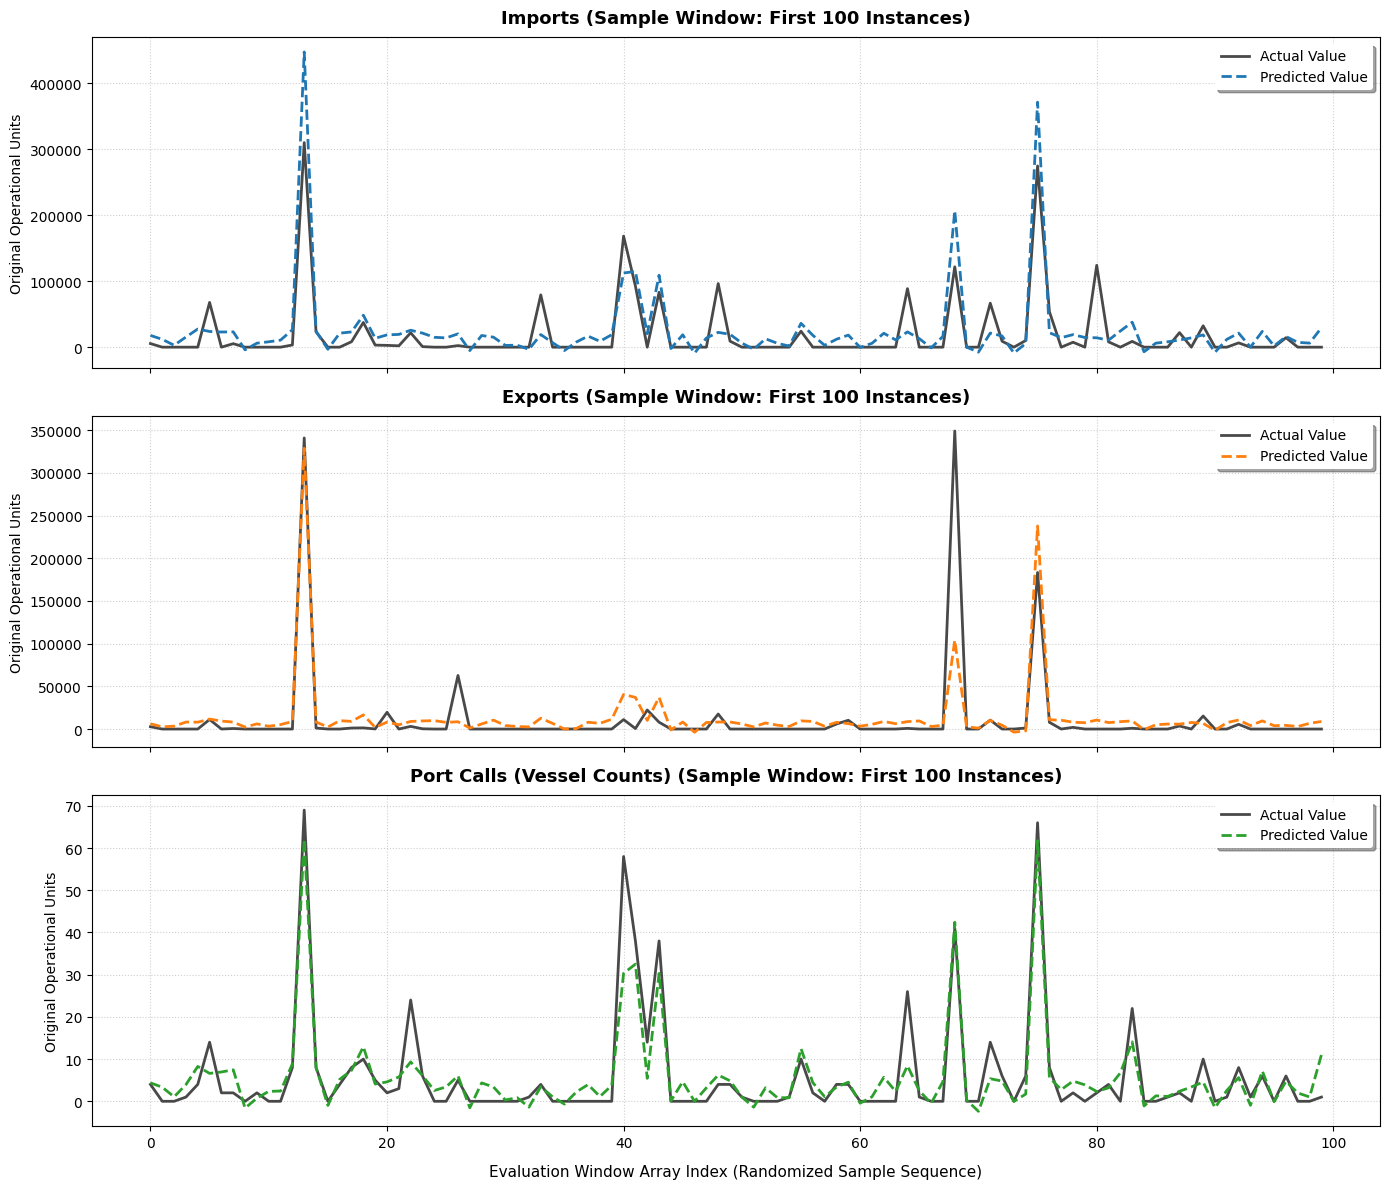

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate multi-head predictions from your trained network
print("🔮 Generating model predictions across tracking windows...")
predictions = ports_lstm_model.predict(
    x={"sequence_input": X_seq, "port_id_input": X_port}, 
    batch_size=32, 
    verbose=1
)

# Unpack the first three continuous regression heads
pred_imp_scaled = predictions[0].flatten()
pred_exp_scaled = predictions[1].flatten()
pred_cal_scaled = predictions[2].flatten()

# 2. Reconstruct 3-column matrices to safely apply inverse_transform
actual_scaled_matrix = np.column_stack([y_imp, y_exp, y_cal])
pred_scaled_matrix = np.column_stack([pred_imp_scaled, pred_exp_scaled, pred_cal_scaled])

# Reverse the global MinMaxScaler back to real-world operational units
actual_original = global_scaler.inverse_transform(actual_scaled_matrix)
pred_original = global_scaler.inverse_transform(pred_scaled_matrix)

# Isolate the true vs. predicted vectors in their original scale
true_imp, true_exp, true_cal = actual_original[:, 0], actual_original[:, 1], actual_original[:, 2]
final_pred_imp, final_pred_exp, final_pred_cal = pred_original[:, 0], pred_original[:, 1], pred_original[:, 2]

# 3. Build the Evaluation Dashboard
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plotting configuration array
plot_configs = [
    {"title": "Imports", "true": true_imp, "pred": final_pred_imp, "color": "#1f77b4"},
    {"title": "Exports", "true": true_exp, "pred": final_pred_exp, "color": "#ff7f0e"},
    {"title": "Port Calls (Vessel Counts)", "true": true_cal, "pred": final_pred_cal, "color": "#2ca02c"}
]

# Define a clean viewing slice (adjust this size to see more or fewer windows)
SAMPLE_WINDOW = min(100, len(X_seq))

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    
    # Plot true historical baselines vs predictions
    ax.plot(config["true"][:SAMPLE_WINDOW], label="Actual Value", color="#1c1c1c", alpha=0.8, linewidth=2)
    ax.plot(config["pred"][:SAMPLE_WINDOW], label="Predicted Value", color=config["color"], linestyle="--", linewidth=2)
    
    # Styling and Context
    ax.set_title(f"{config['title']} (Sample Window: First {SAMPLE_WINDOW} Instances)", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel("Original Operational Units", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True)

# Final formatting adjustments
axes[-1].set_xlabel("Evaluation Window Array Index (Randomized Sample Sequence)", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

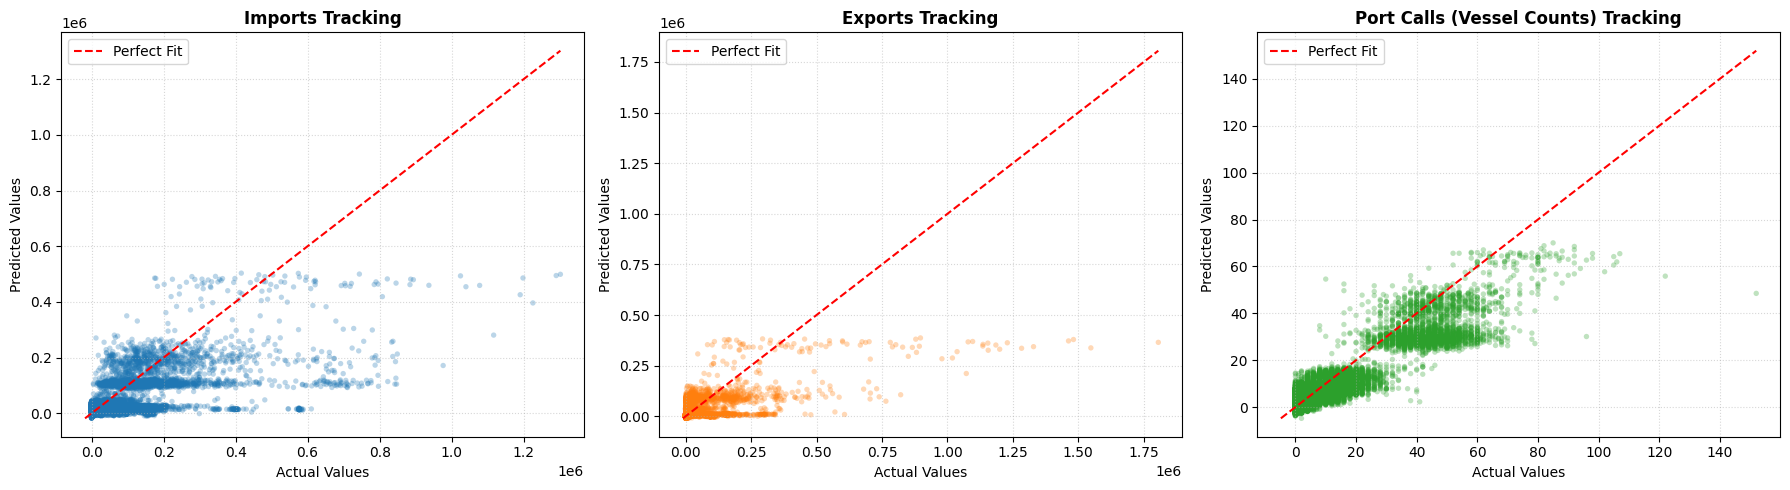

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    
    # Plot all data points as a scatter graph
    ax.scatter(config["true"], config["pred"], color=config["color"], alpha=0.3, edgecolors='none', s=15)
    
    # Draw a 45-degree line representing perfect prediction parity
    max_val = max(config["true"].max(), config["pred"].max())
    min_val = min(config["true"].min(), config["pred"].min())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect Fit')
    
    ax.set_title(config["title"], fontsize=12, fontweight='bold')
    ax.set_xlabel("Actual Values", fontsize=10)
    ax.set_ylabel("Predicted Values", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()